In [3]:
import numpy as np
import scipy.constants as const

import srwave

In [ ]:
#***********Undulator
harmB = srw.SRWLMagFldH() #magnetic field harmonic
harmB.n = 1 #harmonic number
harmB.h_or_v = 'v' #magnetic field plane: horzontal ('h') or vertical ('v')
harmB.B = 1. #magnetic field amplitude [T]
und = srw.SRWLMagFldU([harmB])
und.per = 0.02 #period length [m]
und.nPer = 150 #number of periods (will be rounded to integer)
magFldCnt = srw.SRWLMagFldC([und], array('d', [0]), array('d', [0]), array('d', [0])) #Container of all magnetic field elements

In [ ]:
stkP.allocate(1, 101, 101) #numbers of points vs horizontal and vertical positions (photon energy is not taken into account)
stkP.mesh.zStart = 30. #longitudinal position [m] at which power density has to be calculated
stkP.mesh.xStart = -0.02 #initial horizontal position [m]
stkP.mesh.xFin = 0.02 #final horizontal position [m]
stkP.mesh.yStart = -0.015 #initial vertical position [m]
stkP.mesh.yFin = 0.015 #final vertical position [m]

In [ ]:

eBeam = srw.SRWLPartBeam()
eBeam.Iavg = 0.5 #average current [A]
eBeam.partStatMom1.x = 0. #initial transverse positions [m]
eBeam.partStatMom1.y = 0.
eBeam.partStatMom1.z = 0. #initial longitudinal positions (set in the middle of undulator)
eBeam.partStatMom1.xp = 0 #initial relative transverse velocities
eBeam.partStatMom1.yp = 0
eBeam.partStatMom1.gamma = 3./0.51099890221e-03 #relative energy
sigEperE = 0.00089 #relative RMS energy spread
sigX = 33.33e-06 #horizontal RMS size of e-beam [m]
sigXp = 16.5e-06 #horizontal RMS angular divergence [rad]
sigY = 2.912e-06 #vertical RMS size of e-beam [m]
sigYp = 2.7472e-06 #vertical RMS angular divergence [rad]
#2nd order stat. moments:
eBeam.arStatMom2[0] = sigX*sigX #<(x-<x>)^2> 
eBeam.arStatMom2[1] = 0 #<(x-<x>)(x'-<x'>)>
eBeam.arStatMom2[2] = sigXp*sigXp #<(x'-<x'>)^2> 
eBeam.arStatMom2[3] = sigY*sigY #<(y-<y>)^2>
eBeam.arStatMom2[4] = 0 #<(y-<y>)(y'-<y'>)>
eBeam.arStatMom2[5] = sigYp*sigYp #<(y'-<y'>)^2>
eBeam.arStatMom2[10] = sigEperE*sigEperE #<(E-<E>)^2>/<E>^2


In [4]:
B = 1
lambdau = 20e-3
K = const.e*B*lambdau/(2*np.pi*const.m_e*const.c)

In [28]:
und = srwave.Undulator(period_length=20e-3, nr_periods=150, Ky=K)
fields = srwave.MagnetCnt(magnets=und, fieldtype='undulator')

beam = srwave.radiation.Beam(I=0.5, E=3e9)

energy = und.harmonic_energy(harmn=np.arange(1,21,2), E=3e9, theta=0)

x = np.linspace(-0.02, 0.02, 201)
y = np.linspace(-0.015, 0.015, 201)


arrItotal = 0

for Eph in energy:
    print(Eph)
    SR = srwave.SynchrotronRadiation(energy=Eph, x=x, y=y, d=30, fields=fields, beam=beam)
    SR.calc_wfr()
    arrI, _ = SR.calc_intensity(coords='xy',energy=Eph)
    arrItotal += arrI

1557.5151653323962
4672.5454959971885


RuntimeError: SRW can not compute this case in that mode. Try to reduce Magnetic Field limits and/or Observation range and/or Precision level.

In [27]:
np.arange(1,21,2)

array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19])

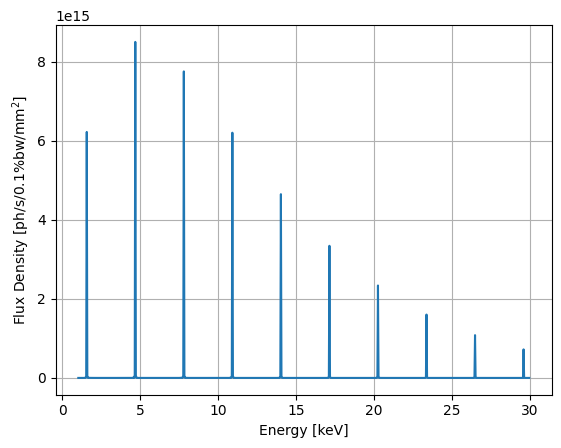

In [26]:
und = srwave.Undulator(period_length=20e-3, nr_periods=150, Ky=K)
fields = srwave.MagnetCnt(magnets=und, fieldtype='undulator')

beam = srwave.radiation.Beam(I=0.5, E=3e9)


energy = np.linspace(1,30,800) * 1e3
energy = und.adjust_energy(energy,3e9,0)

SR = srwave.SynchrotronRadiation(energy=energy, x=0, y=0, d=30, fields=fields, beam=beam)
SR.calc_wfr()

SR.plot_spectrum()

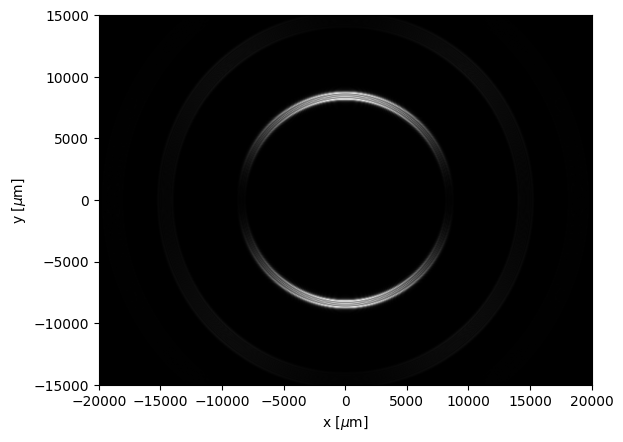

In [31]:
und = srwave.Undulator(period_length=20e-3, nr_periods=150, Ky=K)
fields = srwave.MagnetCnt(magnets=und, fieldtype='undulator')

beam = srwave.radiation.Beam(I=0.5, E=3e9)

Eph = und.harmonic_energy(harmn=0.5, E=3e9, theta=0)

x = np.linspace(-0.02, 0.02, 501)
y = np.linspace(-0.015, 0.015, 501)


SR = srwave.SynchrotronRadiation(energy=Eph, x=x, y=y, d=30, fields=fields, beam=beam)
SR.calc_wfr()

SR.plot_intensity(coords='xy',energy=Eph)